# Exploratory Data Analysis on Retail Sales Data

## Objective
To analyze retail sales data to uncover patterns, trends, and insights
that help understand business performance and customer behavior.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [5]:
import os
os.getcwd()

'C:\\Users\\saran'

In [8]:
import os
os.chdir(r"C:\Users\saran\OneDrive\Documents\GitHub\SarangiBendre-profile\OIBSIP\EDA_Retail_Sales")

In [9]:
df = pd.read_csv("data/retail_sales.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [10]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [11]:
df.shape

(1000, 9)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

STEP 1: Convert Date column to datetime

In [14]:
df['Date'] = pd.to_datetime(df['Date'])

In [15]:
df.dtypes

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

STEP 2: Check Age sanity

In [16]:
df['Age'].describe()

count    1000.00000
mean       41.39200
std        13.68143
min        18.00000
25%        29.00000
50%        42.00000
75%        53.00000
max        64.00000
Name: Age, dtype: float64

STEP 3: Check Gender consistency

In [18]:
df['Gender'].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

STEP 4: Check Product Categories

In [19]:
df['Product Category'].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

Sales by Product Category

In [20]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()
category_sales

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

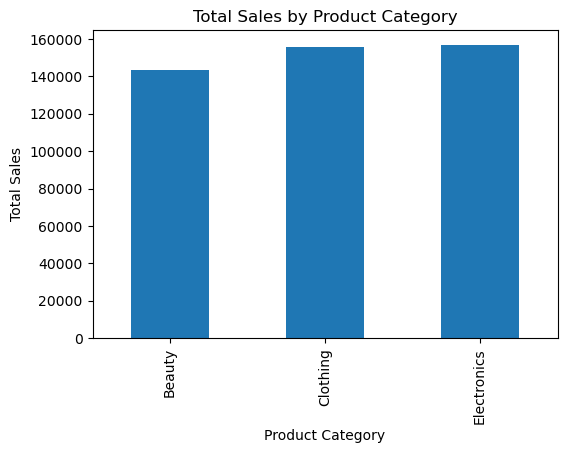

In [21]:
plt.figure(figsize=(6,4))
category_sales.plot(kind='bar')
plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()

Gender-wise Spending

In [22]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()
gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

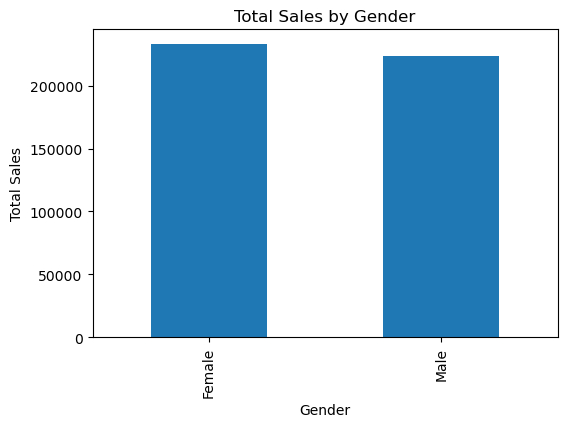

In [23]:
plt.figure(figsize=(6,4))
gender_sales.plot(kind='bar')
plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")
plt.show()

Age distribution

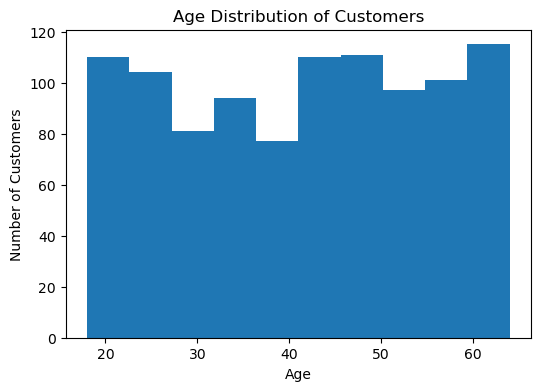

In [24]:
plt.figure(figsize=(6,4))
plt.hist(df['Age'], bins=10)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

## Key Insights

1. Electronics is the highest revenue-generating product category, indicating higher-value purchases compared to other categories.

2. Female customers contribute slightly more to total sales than male customers, despite nearly equal representation in the dataset.

3. The majority of customers fall within the 25–60 age range, with peak concentration around middle-aged groups, suggesting this demographic as the primary target market.

4. The dataset is clean with no duplicate records and realistic age values, making the analysis reliable.
